In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style="whitegrid")

# Unidad 6 - Ajustes y modelos 1

**Ejercicio N° 1**

En un análisis de calidad de un producto alimenticio de un determinado laboratorio se desea conocer la relación entre el tiempo de exposición, de una misma cantidad de producto, a una temperatura de 180° y el número de bacterias sobrevivientes. Para ello se realizó un experimento en 12 observaciones de diferentes tiempos de exposición donde se observó la cantidad de bacterias sobrevivientes. 

Proponga  un análisis exploratorio de los datos y comente la relación que se puede observar entre las variables. ¿Es posible ajustar un modelo de regresión simple entre estas variables?

De ser así indique cual sería el modelo propuesto en relación al problema que busca modelizar y ajustelo con las librerías propuestas en clase. Proponga un analisis de residuos.  Y explique las salidas del modelo (coeficientes, R2, y lo que le parezca pertinente). 

Escriba sus conclusiones al respecto

In [11]:
bacterias=pd.read_csv('./Datasets Práctica Nº 6/Parte_1/bacterias.csv',sep=';')
bacterias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               12 non-null     int64
 1   bacterias_vivas  12 non-null     int64
 2   segundos         12 non-null     int64
dtypes: int64(3)
memory usage: 420.0 bytes


In [18]:
bacterias.columns.tolist()

['ID', 'bacterias_vivas', 'segundos ']

In [19]:
bacterias.columns = bacterias.columns.str.strip()

In [20]:
bacterias.isnull().sum()

ID                 0
bacterias_vivas    0
segundos           0
dtype: int64

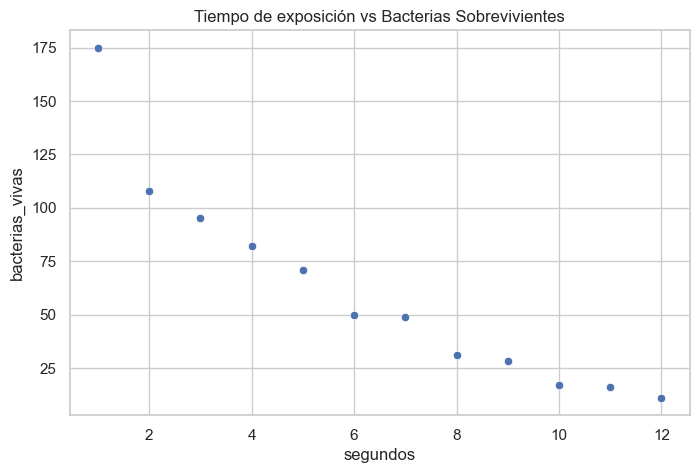

In [ ]:
# 1. Exploratorio
plt.figure(figsize=(8,5))
sns.scatterplot(data=bacterias, x='segundos', y='bacterias_vivas')
plt.title("Tiempo de exposición vs Bacterias Sobrevivientes")
plt.show()

In [ ]:
# 2. Modelo de Regresión Simple
## La fórmula 'bacterias_vivas ~ segundos' le indica a statsmodels que:
####   - bacterias_vivas es la variable respuesta (Y)
####   - segundos es la variable predictora (X)

modelo = smf.ols(formula = 'bacterias_vivas ~ segundos', data = bacterias).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        bacterias_vivas   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     66.51
Date:               do., 31 may. 2026   Prob (F-statistic):           9.94e-06
Time:                        20:17:39   Log-Likelihood:                -50.815
No. Observations:                  12   AIC:                             105.6
Df Residuals:                      10   BIC:                             106.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    142.1970     11.262     12.627      0.0

### El modelo ajustado es entonces:
* $\hat{y} = -142.197 + 12.479*x$

La interpretacion es que cuando el tiempo es 0, hay 142.197(beta0) bacterias y a medida que avanza el tiempo el numero se reduce(pendiente negativa)

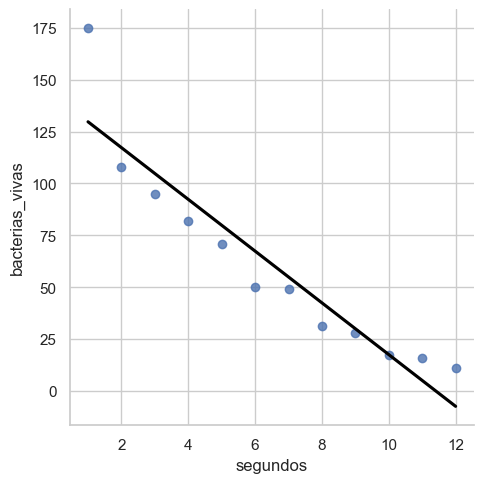

In [29]:
#linear model plot, para representar estimaciones de modelo
sns.lmplot(x='segundos',y='bacterias_vivas',data=bacterias,ci=None, line_kws={'color':'black'})

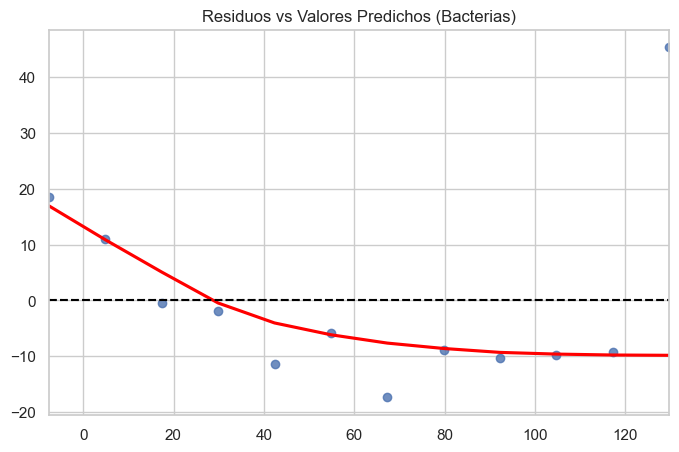

In [32]:
plt.figure(figsize=(8,5))
sns.residplot(x=modelo.fittedvalues, y=modelo.resid, lowess=True, line_kws={'color': 'red'})
plt.title("Residuos vs Valores Predichos (Bacterias)")
plt.axhline(0, color='black', linestyle='--')
plt.show()

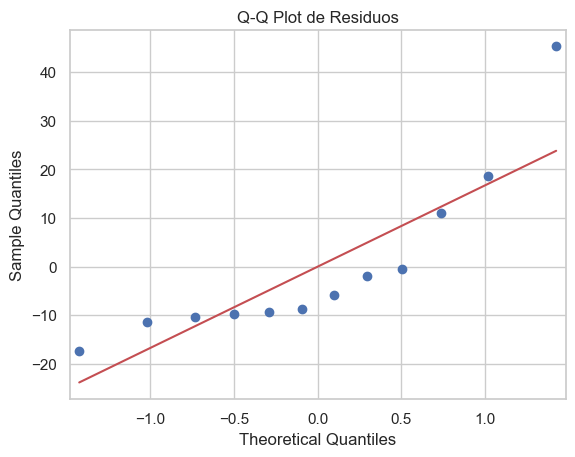

In [34]:
# Normalidad de Residuos
sm.qqplot(modelo.resid, line='s')
plt.title("Q-Q Plot de Residuos")
plt.show()


  **Ejercicio N° 2**

Se desea estudiar la relación de los años de educación y la esperanza de vida. Para ello se cuenta con un dataset de datos del año 2015. 
Proponga  un análisis exploratorio de los datos y comente la relación que se puede observar entre las variables. ¿Es posible ajustar un modelo de regresión simple entre estas variables?

De ser así indique escriba cual sería el modelo propuesto en realción al problema que busca modelizar y ajustelo con las librerías propuestas en clase. Proponga un analisis de residuos.  Y explique las salidas del modelo  (coeficientes, R2, y lo que le parezca pertinente). 

 Escriba sus conclusiones al respecto